In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

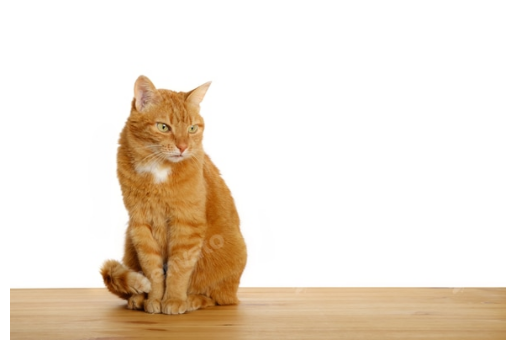

In [2]:
in_path = "cat.jpg"

img = cv2.imread(in_path)
if img is None:
    raise ValueError("Image didn't load. Check the filename/path.")

plt.figure()
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

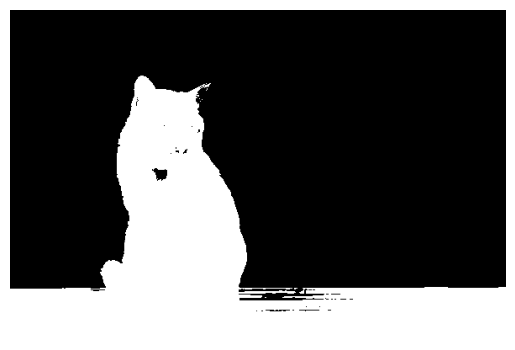

In [3]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

white_ratio = np.mean(binary == 255)
if white_ratio > 0.60:
    binary = cv2.bitwise_not(binary)

binary01 = (binary > 0).astype(np.uint8)

plt.figure()
plt.imshow(binary01, cmap="gray")
plt.axis("off")
plt.show()

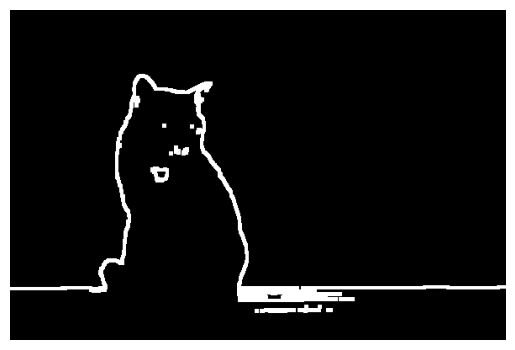

In [4]:
kernel = np.ones((5, 5), np.uint8)

binary255 = (binary01 * 255).astype(np.uint8)

eroded  = cv2.erode(binary255, kernel, iterations=1)
dilated = cv2.dilate(binary255, kernel, iterations=1)

boundary255 = cv2.subtract(dilated, eroded)
boundary01  = (boundary255 > 0).astype(np.uint8)

plt.figure()
plt.imshow(boundary01, cmap="gray")
plt.axis("off")
plt.show()

In [5]:
out_path = "boundary.png"
cv2.imwrite(out_path, boundary255)

True